In [1]:
# ============================================================
# Multiple Linear Regression - Basics
# ============================================================

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 2. Create Dataset
# Features:
# R&D Spend
# Administration
# Marketing Spend
#
# Target:
# Profit

data = {
    "R&D Spend": [165349, 162598, 153442, 144372, 142107,
                  131877, 134615, 130298, 120542, 123334,
                  101913, 100672, 93863, 91992, 119943,
                  114523, 78013, 94657, 91749, 86419],

    "Administration": [136898, 151377, 101145, 118671, 91391,
                       99814, 147198, 145530, 148719, 108679,
                       110594, 91790, 127320, 135495, 156547,
                       122616, 121597, 145077, 114175, 153514],

    "Marketing Spend": [471784, 443899, 407935, 383200, 366168,
                        362861, 127716, 323877, 311613, 304982,
                        229161, 249744, 249839, 252664, 256513,
                        261776, 264346, 282574, 294919, 0],

    "Profit": [192261, 191792, 191050, 182902, 166188,
               156991, 156122, 155752, 152211, 149759,
               146121, 144259, 141585, 134307, 132602,
               129917, 126992, 125370, 124267, 122776]
}

df = pd.DataFrame(data)

df.head()

,R&D Spend,Administration,Marketing Spend,Profit
0,165349,136898,471784,192261
1,162598,151377,443899,191792
2,153442,101145,407935,191050
3,144372,118671,383200,182902
4,142107,91391,366168,166188


In [3]:
# 3. Check Dataset Information

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Shape: (20, 4)

Columns:
Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit'], dtype='object')

Data Types:
R&D Spend          int64
Administration     int64
Marketing Spend    int64
Profit             int64
dtype: object

Missing Values:
R&D Spend          0
Administration     0
Marketing Spend    0
Profit             0
dtype: int64

Statistical Summary:


,R&D Spend,Administration,Marketing Spend,Profit
count,20.00000,20.000000,20.00000,20.000000
mean,119113.90000,126407.350000,292278.55000,151161.200000
std,26215.60379,21380.841014,106026.62726,23249.357788
min,78013.00000,91391.000000,0.00000,122776.000000
25%,94458.50000,110115.250000,251957.75000,131930.750000
50%,120242.50000,124968.000000,288746.50000,147940.000000
75%,136488.00000,145947.000000,363687.75000,159290.250000
max,165349.00000,156547.000000,471784.00000,192261.000000


In [4]:
# 4. Separate Features and Target

X = df[["R&D Spend", "Administration", "Marketing Spend"]]

y = df["Profit"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   R&D Spend  Administration  Marketing Spend
0     165349          136898           471784
1     162598          151377           443899
2     153442          101145           407935
3     144372          118671           383200
4     142107           91391           366168

Target:
0    192261
1    191792
2    191050
3    182902
4    166188
Name: Profit, dtype: int64


In [5]:
# 5. Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16, 3)
Testing Data: (4, 3)


In [6]:
# 6. Create Multiple Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [7]:
# 7. Model Coefficients and Intercept

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: 85682.22267501615

Coefficients:
R&D Spend : 0.6837850805957838
Administration : -0.1582284914884201
Marketing Spend : 0.014442155117226518


Profit =
Intercept
+ Coefficient₁ × R&D Spend
+ Coefficient₂ × Administration
+ Coefficient₃ × Marketing Spend

In [8]:
# 8. Make Predictions

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[183897.81564849 131532.9297294  148370.60634571 179323.01306807]


In [9]:
# 9. Compare Actual vs Predicted Values

comparison = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred
})

comparison

,Actual Profit,Predicted Profit
0,192261,183897.815648
1,125370,131532.929729
2,129917,148370.606346
3,191792,179323.013068


In [10]:
# 10. Calculate Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 11362.176839637534
Mean Squared Error (MSE): 150983944.40448618
Root Mean Squared Error (RMSE): 12287.552417161287
R² Score: 0.8546700544184909


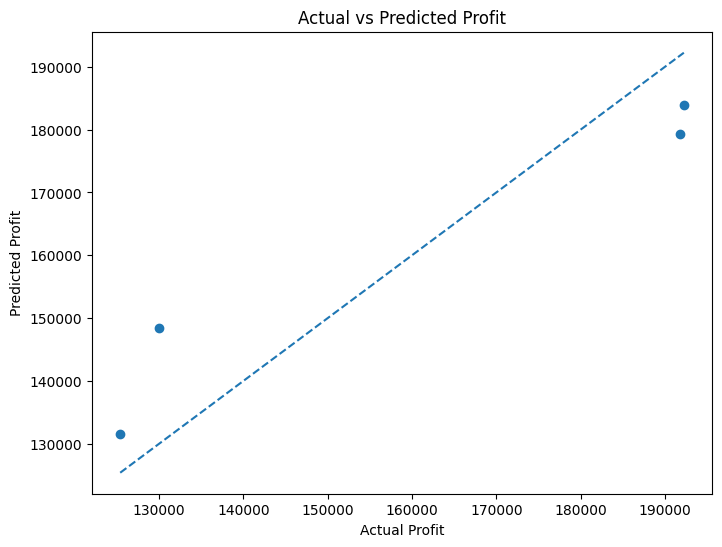

In [11]:
# 11. Actual vs Predicted Plot

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

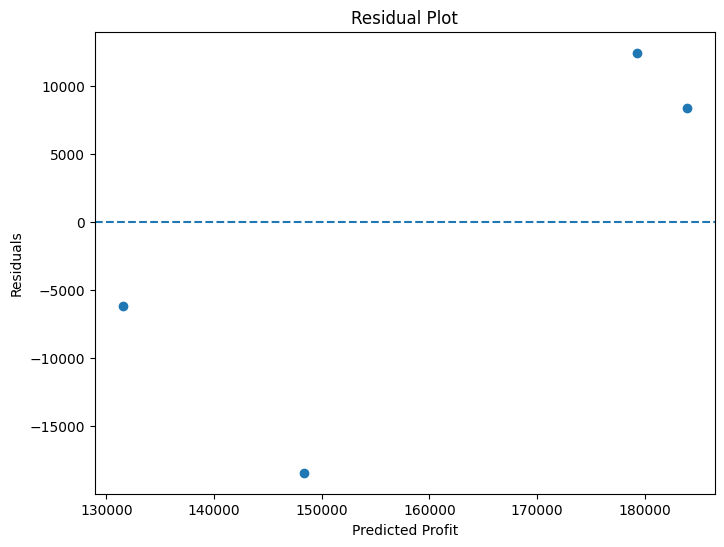

In [12]:
# 12. Residuals

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Profit")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [13]:
# 13. Predict Profit for a New Company

new_company = pd.DataFrame({
    "R&D Spend": [150000],
    "Administration": [120000],
    "Marketing Spend": [350000]
})

predicted_profit = model.predict(new_company)

print("Predicted Profit:", predicted_profit[0])

Predicted Profit: 174317.32007680257


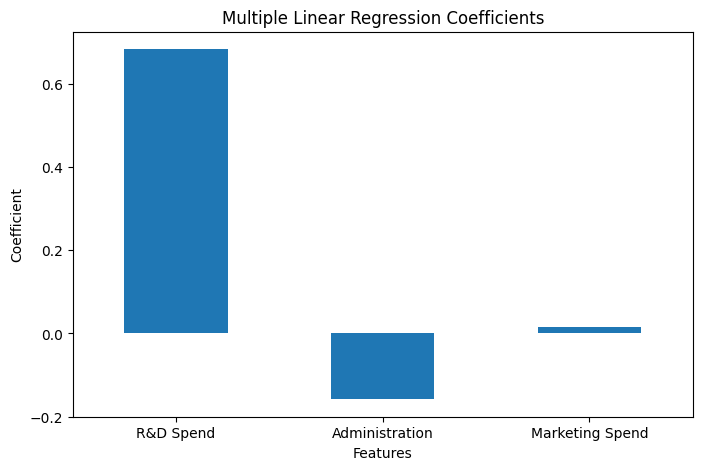

In [14]:
# 14. Visualize Feature Coefficients

coefficients = pd.Series(
    model.coef_,
    index=X.columns
)

coefficients.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Multiple Linear Regression Coefficients")

plt.xticks(rotation=0)
plt.show()